In [1]:
import scanpy as sc
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib import colors as mcolors
import warnings
warnings.filterwarnings("ignore")


def plot_spatial_compact_fast(
    ad,
    color="leiden_2",
    groupby="sample_id",
    spot_size=8,
    cols=3,
    height=8,
    legend_col_width=1.2,
    palette=None,            # dict {cat:"#hex"} or list
    rasterized=True,         # big speedup for vectors/PDFs
    invert_y=True,           # match Scanpy orientation
    dpi=120,                 # lower dpi → faster
):
    # ----- 0) Preconditions -----
    if "spatial" not in ad.obsm:
        raise ValueError("ad.obsm['spatial'] is required.")

    coords = np.asarray(ad.obsm["spatial"])[:, :2]
    cats = ad.obs[color].astype("category")
    cat_names = cats.cat.categories
    cat_codes = cats.cat.codes.to_numpy()  # -1 for NaN

    # ----- 1) Build shared palette (RGBA array) -----
    if isinstance(palette, dict):
        col_list = [palette[c] for c in cat_names]
    elif isinstance(palette, (list, tuple)):
        if len(palette) < len(cat_names):
            raise ValueError("Palette shorter than number of categories.")
        col_list = list(palette)[:len(cat_names)]
    elif f"{color}_colors" in ad.uns:
        col_list = list(ad.uns[f"{color}_colors"])
        if len(col_list) != len(cat_names):
            raise ValueError(f"{color}_colors length != categories.")
    else:
        base = getattr(getattr(__import__("scanpy").pl.palettes, "default_64", []), "__iter__", None)
        base = list(__import__("scanpy").pl.palettes.default_64
                    if hasattr(__import__("scanpy").pl.palettes, "default_64")
                    else __import__("scanpy").pl.palettes.default_102)
        reps = int(np.ceil(len(cat_names) / len(base)))
        col_list = (base * reps)[:len(cat_names)]

    # store for consistency elsewhere
    ad.uns[f"{color}_colors"] = col_list

    # convert to RGBA float array for fast indexing
    rgba = np.array([mcolors.to_rgba(c) for c in col_list], dtype=float)
    # map codes -> rgba; handle -1 (NaN) as transparent
    colors_arr = np.empty((cat_codes.size, 4), dtype=float)
    colors_arr[cat_codes >= 0] = rgba[cat_codes[cat_codes >= 0]]
    colors_arr[cat_codes < 0] = (0, 0, 0, 0)

    # ----- 2) Precompute group indices (no per-iteration masks) -----
    gvals = ad.obs[groupby].astype(str).to_numpy()
    uniq_groups, gcodes = np.unique(gvals, return_inverse=True)
    # list of index arrays per group
    group_indices = [np.flatnonzero(gcodes == gi) for gi in range(len(uniq_groups))]

    # ----- 3) Figure layout -----
    n = len(uniq_groups)
    rows = int(np.ceil(n / cols))
    panel_w = height * cols * 0.6 / rows
    fig_w = panel_w + legend_col_width

    plt.ioff()  # speed: disable interactive redraws
    fig = plt.figure(figsize=(fig_w, height), dpi=dpi, constrained_layout=False)
    gs = GridSpec(
        rows, cols + 1, figure=fig,
        width_ratios=[1]*cols + [legend_col_width / (fig_w - legend_col_width)],
        wspace=0.02, hspace=0.02
    )

    # ----- 4) Panels (fast scatter) -----
    for i, sid in enumerate(uniq_groups):
        r, c = divmod(i, cols)
        ax = fig.add_subplot(gs[r, c])

        idx = group_indices[i]
        if idx.size:
            xy = coords[idx]
            # note: turn off edgecolor & use rasterized for speed
            sca = ax.scatter(
                xy[:, 0], xy[:, 1],
                c=colors_arr[idx],
                s=spot_size,
                marker='o',
                linewidths=0,
                rasterized=rasterized
            )
        ax.set_title(str(sid), fontsize=9, pad=2)
        ax.set_aspect("equal")
        if invert_y:
            ax.invert_yaxis()
        ax.set_axis_off()

    # blank unused
    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        fig.add_subplot(gs[r, c]).axis("off")

    # ----- 5) Legend (single, shared) -----
    ax_leg = fig.add_subplot(gs[:, -1])
    ax_leg.axis("off")
    handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=col_list[k], markersize=7, label=str(cat))
        for k, cat in enumerate(cat_names)
    ]
    ax_leg.legend(handles=handles, title=color, frameon=False, loc="center left")

    fig.subplots_adjust(left=0.01, right=0.98, top=0.98, bottom=0.02, wspace=0.02, hspace=0.02)
    plt.ion()  # ✅ correct
    plt.show()

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
adata = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_annotation_with_rbd.h5ad')

In [24]:
list(adata.obs.cell_class.unique())

['Oligodendrocytes',
 'Excitatory Neurons',
 'Astrocytes',
 'Microglia',
 'Neurons',
 'Endothelial Cells',
 'GABAergic Neurons',
 'Oligodendrocyte Precursor Cells',
 'Neural Stem Cells',
 'Medium Spiny Neurons',
 'Endocrine Cells',
 'Myocytes']

In [29]:
adata_OL = adata[adata.obs.cell_class.isin(['Oligodendrocytes','Oligodendrocyte Precursor Cells'])]

In [30]:
sc.tl.pca(adata_OL, n_comps=50, svd_solver="arpack")
sc.pp.neighbors(adata_OL, n_neighbors=20, n_pcs=30)  # tune n_pcs by variance ratio if you like
sc.tl.umap(adata_OL, min_dist=0.3, spread=1.0)

In [68]:
import matplotlib as mpl
mpl.rcdefaults()

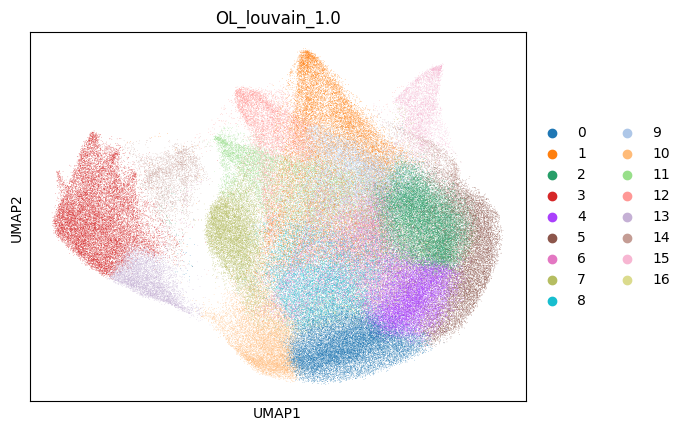

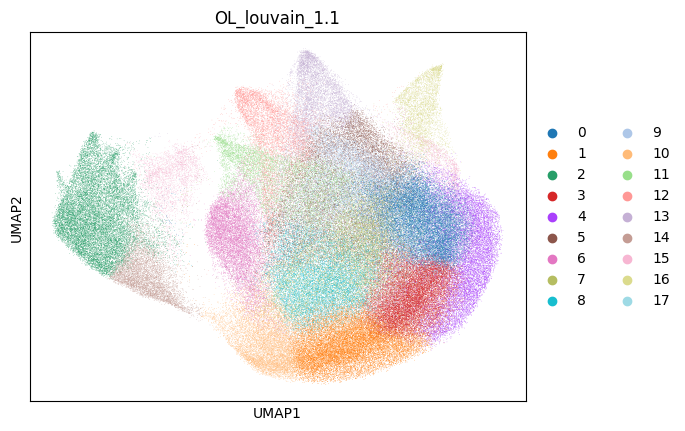

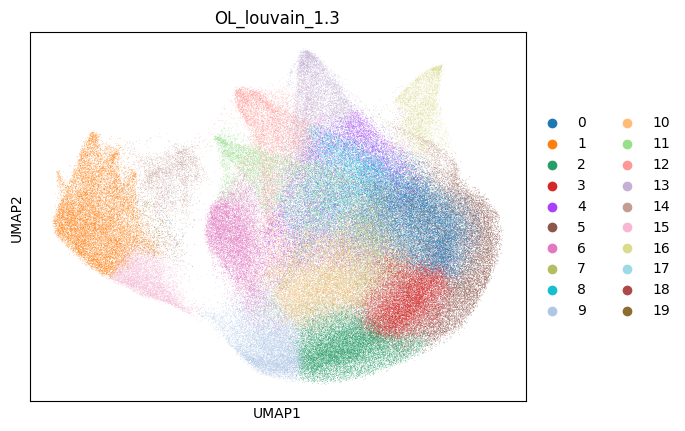

In [72]:
for res in [1.0, 1.1, 1.3]:
    sc.tl.louvain(adata_OL, resolution=res, key_added=f"OL_louvain_{res}")
    sc.pl.umap(adata_OL, color = 'OL_louvain_'+str(res))

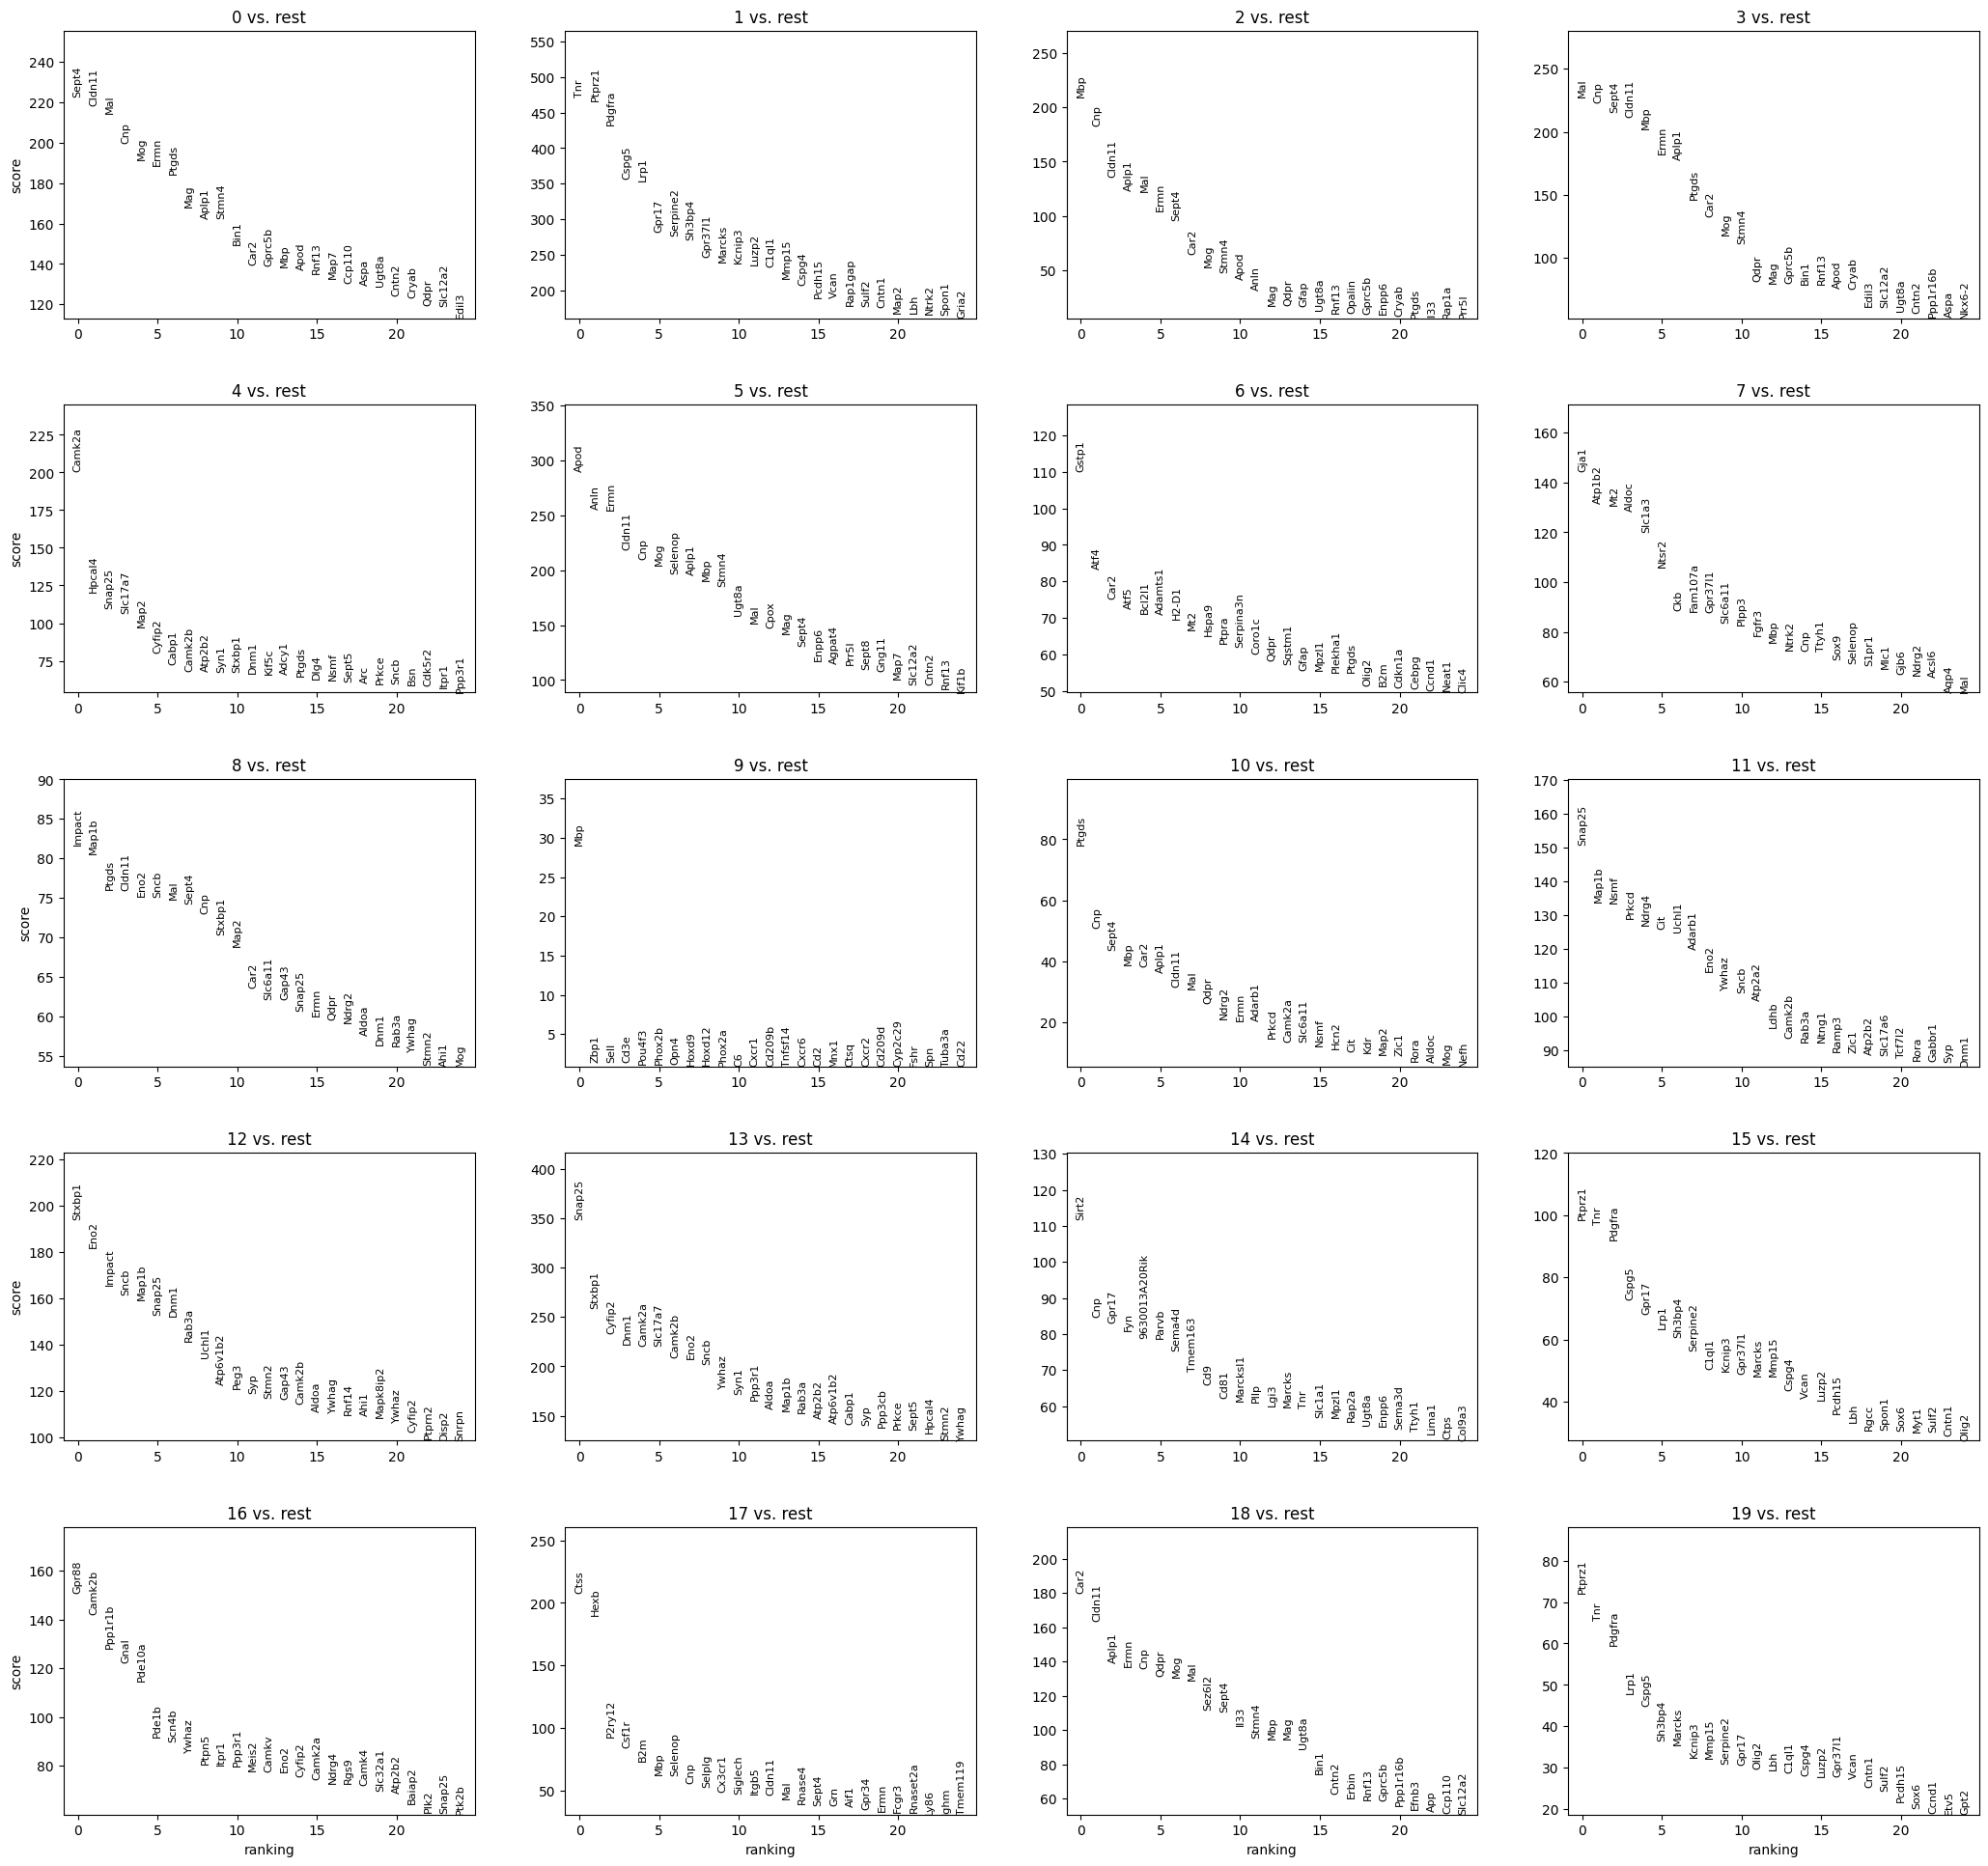

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,Sept4,222.536789,1.749319,0.0,0.0
1,0,Cldn11,218.338959,1.968922,0.0,0.0
2,0,Mal,214.417816,1.981577,0.0,0.0
3,0,Cnp,199.643402,1.459793,0.0,0.0
4,0,Mog,191.736465,2.128389,0.0,0.0


In [73]:
# --- Find marker genes per cluster ---
sc.tl.rank_genes_groups(adata_OL, groupby="OL_louvain_1.3", method="t-test")
sc.pl.rank_genes_groups(adata_OL, n_genes=25, sharey=False)

# get a tidy table of top markers
markers = sc.get.rank_genes_groups_df(adata_OL, group=None)
markers.head()

In [74]:
import pandas as pd

In [75]:
marker_genes = pd.DataFrame({
    group: adata_OL.uns['rank_genes_groups']['names'][group][:10]
    for group in adata_OL.uns['rank_genes_groups']['names'].dtype.names
})
for col in marker_genes.columns: 
    print(col)
    genes = marker_genes[col].tolist()
    print(" ".join(genes))
    print(' ')

0
Sept4 Cldn11 Mal Cnp Mog Ermn Ptgds Mag Aplp1 Stmn4
 
1
Tnr Ptprz1 Pdgfra Cspg5 Lrp1 Gpr17 Serpine2 Sh3bp4 Gpr37l1 Marcks
 
2
Mbp Cnp Cldn11 Aplp1 Mal Ermn Sept4 Car2 Mog Stmn4
 
3
Mal Cnp Sept4 Cldn11 Mbp Ermn Aplp1 Ptgds Car2 Mog
 
4
Camk2a Hpcal4 Snap25 Slc17a7 Map2 Cyfip2 Cabp1 Camk2b Atp2b2 Syn1
 
5
Apod Anln Ermn Cldn11 Cnp Mog Selenop Aplp1 Mbp Stmn4
 
6
Gstp1 Atf4 Car2 Atf5 Bcl2l1 Adamts1 H2-D1 Mt2 Hspa9 Ptpra
 
7
Gja1 Atp1b2 Mt2 Aldoc Slc1a3 Ntsr2 Ckb Fam107a Gpr37l1 Slc6a11
 
8
Impact Map1b Ptgds Cldn11 Eno2 Sncb Mal Sept4 Cnp Stxbp1
 
9
Mbp Zbp1 Sell Cd3e Pou4f3 Phox2b Opn4 Hoxd9 Hoxd12 Phox2a
 
10
Ptgds Cnp Sept4 Mbp Car2 Aplp1 Cldn11 Mal Qdpr Ndrg2
 
11
Snap25 Map1b Nsmf Prkcd Ndrg4 Cit Uchl1 Adarb1 Eno2 Ywhaz
 
12
Stxbp1 Eno2 Impact Sncb Map1b Snap25 Dnm1 Rab3a Uchl1 Atp6v1b2
 
13
Snap25 Stxbp1 Cyfip2 Dnm1 Camk2a Slc17a7 Camk2b Eno2 Sncb Ywhaz
 
14
Sirt2 Cnp Gpr17 Fyn 9630013A20Rik Parvb Sema4d Tmem163 Cd9 Cd81
 
15
Ptprz1 Tnr Pdgfra Cspg5 Gpr17 Lrp1 Sh3bp4 Serpine2 C1q

In [76]:
marker_genes = pd.DataFrame({
    group: adata_OL.uns['rank_genes_groups']['names'][group][:4]
    for group in adata_OL.uns['rank_genes_groups']['names'].dtype.names
})


In [77]:
cellclass_markers_top4 = {}
for col in marker_genes.columns: 
    print(col)
    genes = marker_genes[col].tolist()
    print(" ".join(genes))
    print(' ')
    cellclass_markers_top4[col] = genes

0
Sept4 Cldn11 Mal Cnp
 
1
Tnr Ptprz1 Pdgfra Cspg5
 
2
Mbp Cnp Cldn11 Aplp1
 
3
Mal Cnp Sept4 Cldn11
 
4
Camk2a Hpcal4 Snap25 Slc17a7
 
5
Apod Anln Ermn Cldn11
 
6
Gstp1 Atf4 Car2 Atf5
 
7
Gja1 Atp1b2 Mt2 Aldoc
 
8
Impact Map1b Ptgds Cldn11
 
9
Mbp Zbp1 Sell Cd3e
 
10
Ptgds Cnp Sept4 Mbp
 
11
Snap25 Map1b Nsmf Prkcd
 
12
Stxbp1 Eno2 Impact Sncb
 
13
Snap25 Stxbp1 Cyfip2 Dnm1
 
14
Sirt2 Cnp Gpr17 Fyn
 
15
Ptprz1 Tnr Pdgfra Cspg5
 
16
Gpr88 Camk2b Ppp1r1b Gnal
 
17
Ctss Hexb P2ry12 Csf1r
 
18
Car2 Cldn11 Aplp1 Ermn
 
19
Ptprz1 Tnr Pdgfra Lrp1
 


In [78]:
import matplotlib as mpl
mpl.rcdefaults()

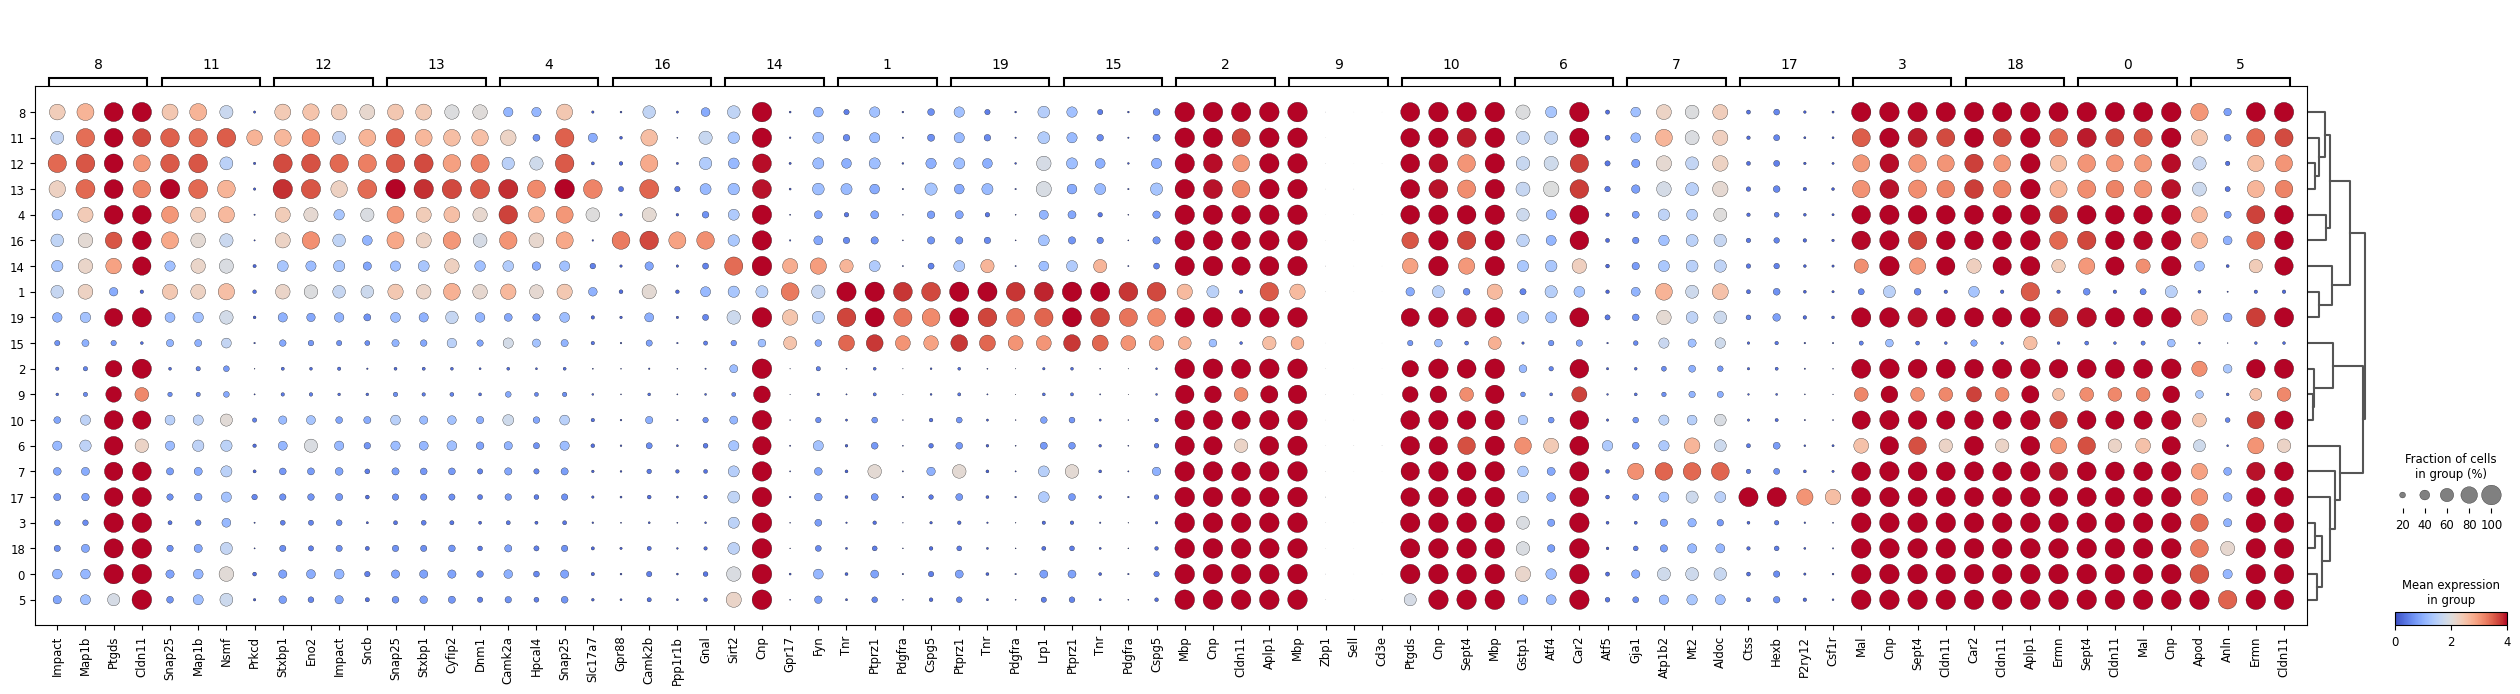

In [87]:
sc.pl.dotplot(
    adata_OL,
    var_names=cellclass_markers_top4,
    groupby="OL_louvain_1.3",
    color_map="coolwarm",
    vmax = 4,
    dendrogram=True
)

In [88]:
import matplotlib as mpl
mpl.rcdefaults()

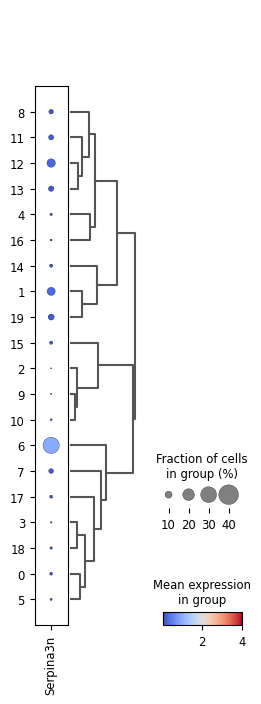

In [89]:
sc.pl.dotplot(
    adata_OL,
    var_names='Serpina3n',
    groupby="OL_louvain_1.3",
    color_map="coolwarm",
    vmax = 4,
    dendrogram=True
)

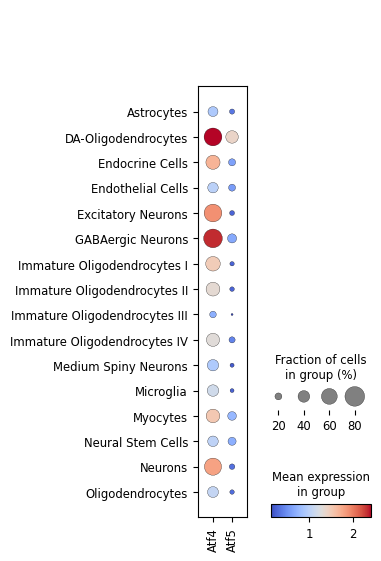

In [135]:
sc.pl.dotplot(
    adata,
    var_names=['Atf4','Atf5'],
    groupby="cell_class",
    color_map="coolwarm",
)

In [90]:
# Core OL lineage and disease/stress signatures (cleaned for missing genes)
OL_SIGNATURES = {
    # lineage states
    "OPC":        ["Pdgfra", "Cspg4", "Sox10", "Tnr"],
    "COP":        ["Dlk1", "Cspg5", "Tnr"],                # removed Bcan
    "NFOL":       ["Enpp6", "Tcf7l2", "Gpr17", "Klk6"],
    "MOL_myelin": ["Mbp", "Mog", "Mag", "Cnp", "Pllp"],   # removed Plp1

    # disease / stress axes
    "DOL_core":   ["Serpina3n", "C4b", "Trib3", "Atf4", "Hsph1", "Hspa1a", "Hspa1b", "Ddit3"],
    "ISR":        ["Atf4", "Trib3", "Ddit3", "Eif2ak3", "Atf5"],         # removed Asns
    "IFN":        ["Stat1", "Irf7", "Isg15", "Gbp2", "Cxcl10"],          # removed Oas1a
    "Astro_react":["Gfap", "Serpina3n"],                                # removed Vim, Lcn2
    "Immune_AP":  ["Cd40", "H2-Ab1", "H2-Aa", "Cd74", "Psmb8", "Psmb9"],  # intact
}

categories: 0, 1, 2, etc.
var_group_labels: OPC, COP, NFOL, etc.


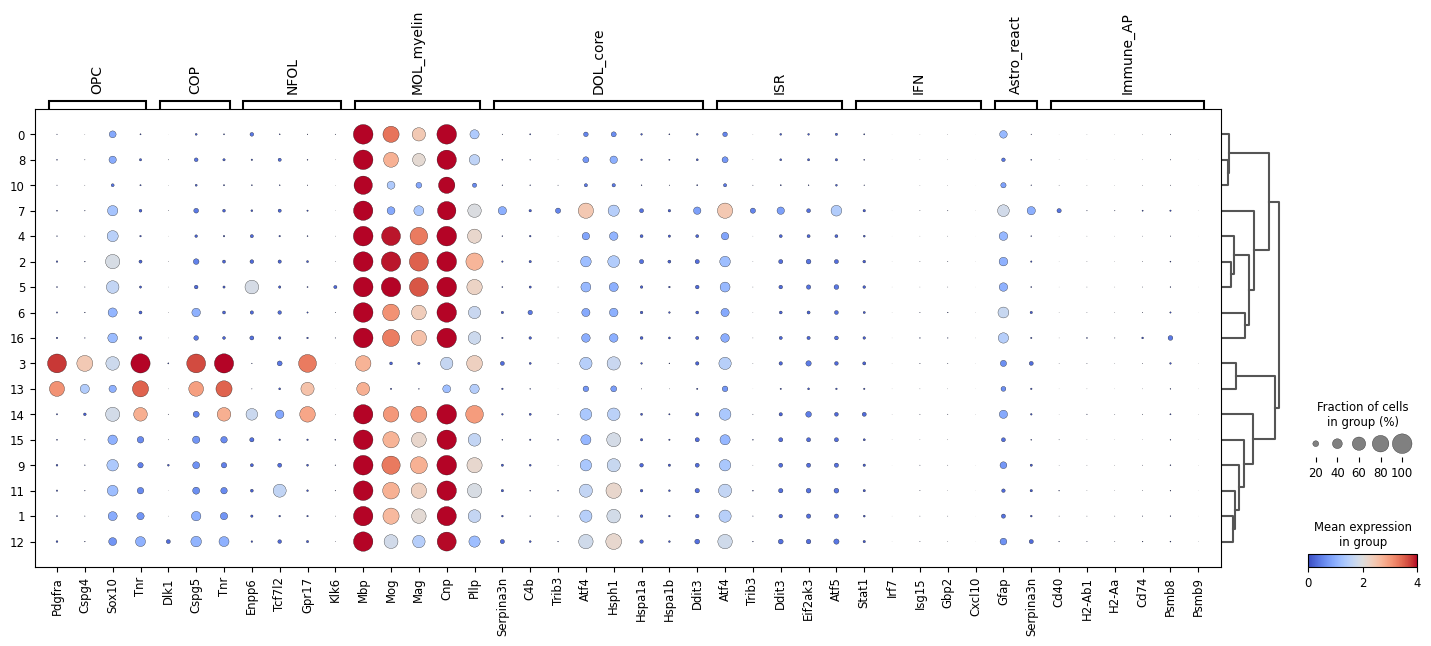

In [91]:
sc.pl.dotplot(
    adata_OL,
    var_names=OL_SIGNATURES,
    groupby="OL_louvain_1.0",
    color_map="coolwarm",
    vmax = 4,
    dendrogram=True
)

In [92]:
import scanpy as sc
import numpy as np

def score_signatures(
    adata,
    signatures: dict,
    prefix: str = "score_",
    ctrl_size: int = 50,
    n_bins: int = 25,
    use_raw: bool = False,
    verbose: bool = True,
):
    """
    Adds one column per signature to adata.obs: f'{prefix}{name}'.
    Auto-filters genes to those present in adata.var_names.
    """
    var_set = set(adata.var_names.astype(str))
    added = []
    for name, genes in signatures.items():
        genes = [g for g in genes if g in var_set]
        if len(genes) == 0:
            if verbose:
                print(f"⚠️  Skipping '{name}': no genes found in var_names.")
            continue
        if verbose:
            print(f"→ Scoring {name:12s} with {len(genes):2d} genes.")
        sc.tl.score_genes(
            adata,
            gene_list=genes,
            score_name=f"{prefix}{name}",
            ctrl_size=ctrl_size,
            n_bins=n_bins,
            use_raw=use_raw
        )
        added.append(f"{prefix}{name}")
    return added

In [93]:
# If you have an OL-only AnnData, use that; otherwise subset:
# adata_OL = adata[adata.obs['cell_class'].isin(['OPC','COP','NFOL','MOL','Oligodendrocytes'])].copy()

cols = score_signatures(adata_OL, OL_SIGNATURES, prefix="score_", ctrl_size=50, n_bins=25, use_raw=False)

# Optional: make a few composite scores (z-scored first)
def z(x):
    x = np.asarray(x, float)
    mu, sd = np.nanmean(x), np.nanstd(x)
    return (x - mu) / (sd if sd > 0 else 1)

obs = adata_OL.obs

# Maturation axis: (myelin) - (OPC)
obs["score_MaturationZ"] = z(obs.get("score_MOL_myelin", 0)) - z(obs.get("score_OPC", 0))

# Disease-tilt: DOL_core + ISR + IFN (averaged z)
obs["score_DiseaseZ"] = np.nanmean(
    np.c_[z(obs.get("score_DOL_core", 0)),
          z(obs.get("score_ISR", 0)),
          z(obs.get("score_IFN", 0))],
    axis=1
)

# Immune-tilt / antigen presentation
obs["score_ImmuneZ"] = z(obs.get("score_Immune_AP", 0))

# Astro contamination check (helpful if OL cluster picks up astro signal)
obs["score_AstroReactZ"] = z(obs.get("score_Astro_react", 0))

→ Scoring OPC          with  4 genes.
→ Scoring COP          with  3 genes.
→ Scoring NFOL         with  4 genes.
→ Scoring MOL_myelin   with  5 genes.
→ Scoring DOL_core     with  8 genes.
→ Scoring ISR          with  5 genes.
→ Scoring IFN          with  5 genes.
→ Scoring Astro_react  with  2 genes.
→ Scoring Immune_AP    with  6 genes.


In [109]:
import matplotlib as mpl
mpl.rcdefaults()

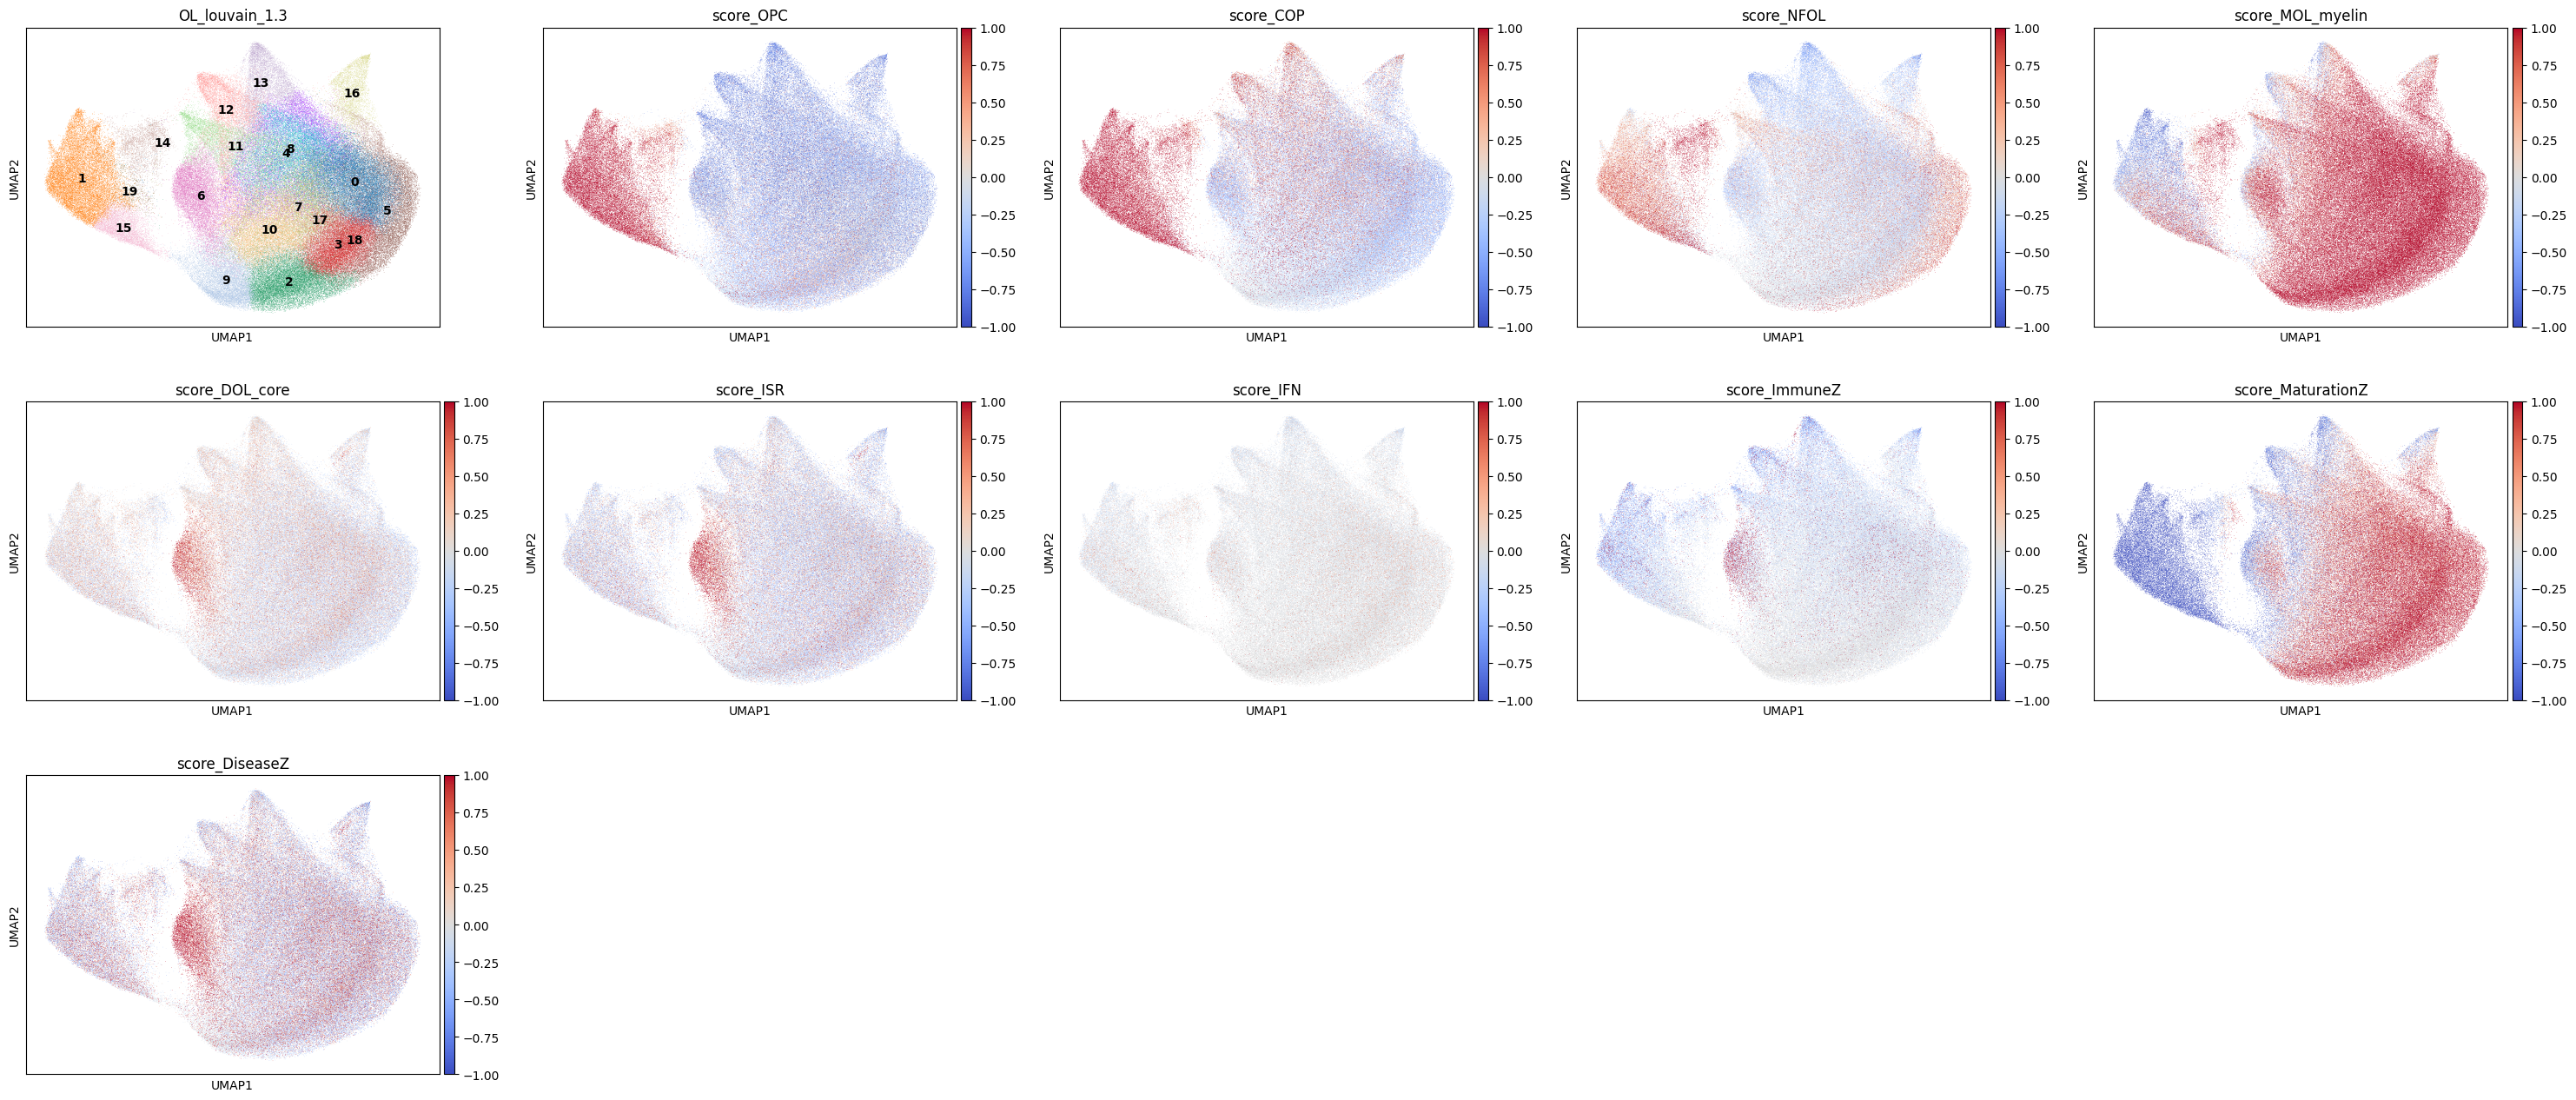

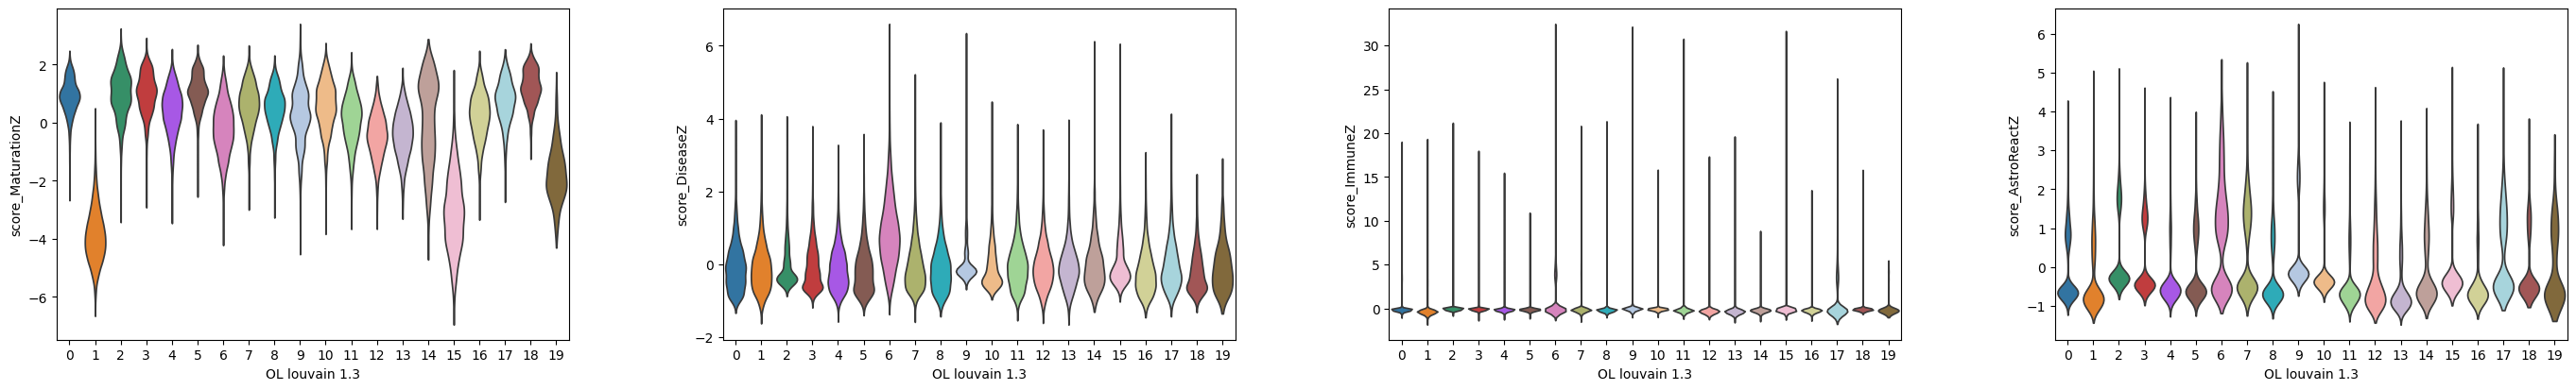

In [98]:
# UMAP overlays
sc.pl.umap(
    adata_OL,
    color=["OL_louvain_1.3","score_OPC","score_COP","score_NFOL","score_MOL_myelin",
           "score_DOL_core","score_ISR","score_IFN","score_ImmuneZ","score_MaturationZ","score_DiseaseZ"],
    vmin=-1, vmax=1, cmap="coolwarm", ncols=5, legend_loc='on data'
)

# Violin by cluster or region
sc.pl.violin(
    adata_OL,
    keys=["score_MaturationZ","score_DiseaseZ","score_ImmuneZ","score_AstroReactZ"],
    groupby="OL_louvain_1.3",
    stripplot=False, jitter=0.2
)

# Dotplot by condition/region (averages per group)
gene_modules = {
    "Lineage":      ["score_OPC","score_COP","score_NFOL","score_MOL_myelin"],
    "Disease_axes": ["score_DOL_core","score_ISR","score_IFN","score_ImmuneZ"]
}
# Scanpy dotplot expects genes; for module scores, use `var_names=...`-style:
# A simple workaround is to copy scores into .obsm and use sc.pl.matrixplot with 'values' arg,
# but easiest is violin/UMAP for module scores. For gene-level dotplots, use your original panels.

In [96]:
adata_OL.obs['OL_louvain_1.0'].cat.categories

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16'],
      dtype='object')

In [101]:
cluster_anno = {
    '0':  'Oligodendrocytes',
    '1':  'Immature Oligodendrocytes I',
    '2':  'Oligodendrocytes',
    '3':  'Oligodendrocytes',
    '4':  'Oligodendrocytes',
    '5':  'Oligodendrocytes',
    '6':  'DA-Oligodendrocytes',
    '7':  'Oligodendrocytes',
    '8':  'Oligodendrocytes',
    '9':  'Oligodendrocytes',
    '10': 'Oligodendrocytes',
    '11': 'Oligodendrocytes',
    '12': 'Oligodendrocytes',
    '13': 'Oligodendrocytes',
    '14': 'Immature Oligodendrocytes II',
    '15': 'Immature Oligodendrocytes III',
    '16': 'Oligodendrocytes',
    '17': 'Oligodendrocytes',
    '18': 'Oligodendrocytes',
    '19': 'Immature Oligodendrocytes IV',

}

In [104]:
adata_OL.obs['OL_ANNO'] = adata_OL.obs['OL_louvain_1.3'].map(cluster_anno)

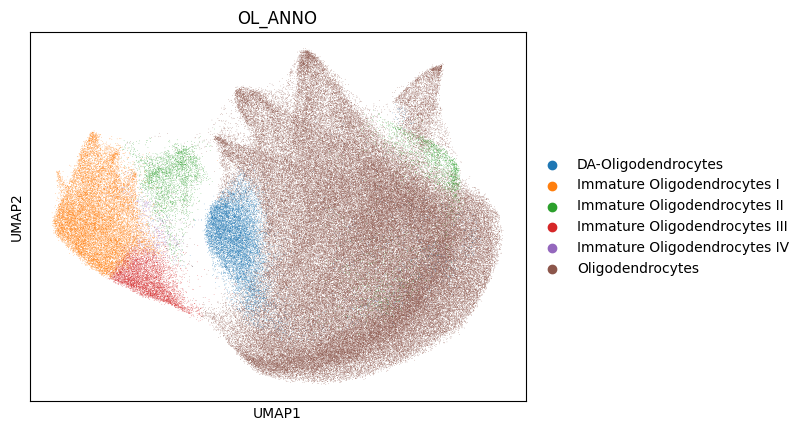

In [105]:
sc.pl.umap(adata_OL, color = 'OL_ANNO')

In [120]:
adata_OL.obs.OL_ANNO.value_counts()

OL_ANNO
Oligodendrocytes                 147628
Immature Oligodendrocytes I       17234
DA-Oligodendrocytes               11778
Immature Oligodendrocytes II       5380
Immature Oligodendrocytes III      5322
Immature Oligodendrocytes IV        649
Name: count, dtype: int64

In [119]:
sample_map = dict(
    zip(
        adata_OL.obs['sample_id'],
        zip(adata_OL.obs['condition'], adata_OL.obs['age'],adata_OL.obs['sex'])
    )
)
sample_map

{'RB4282': ('control', '60', 'male'),
 'RB4350': ('control', '60', 'male'),
 'RB4401': ('mtDSB', '60', 'female'),
 'RB4403': ('mtDSB', '60', 'male'),
 'RB4405': ('mtDSB', '60', 'male'),
 'RB4498': ('control', '60', 'female'),
 'RB4620': ('control', '21', 'male'),
 'RB4627': ('mtDSB', '21', 'male'),
 'RB4630': ('mtDSB', '21', 'male'),
 'RB4653': ('mtDSB', '21', 'female'),
 'RB4658': ('control', '21', 'female'),
 'RB4676': ('control', '21', 'female')}

Plotting OL_ANNO …


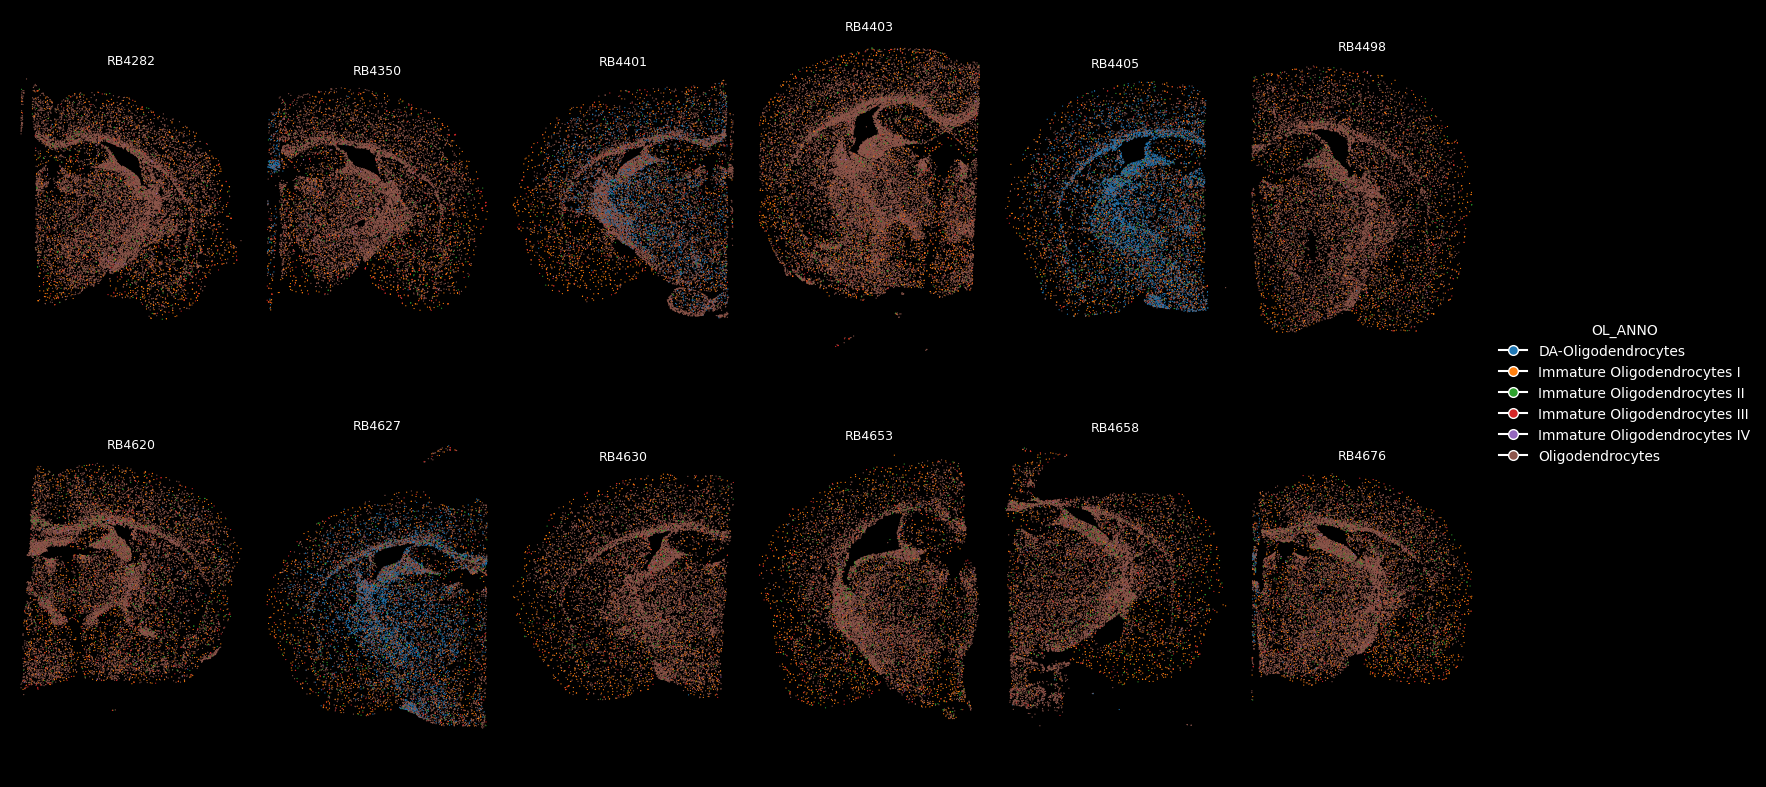

In [107]:
# --- make all axes dark background ---
plt.rcParams.update({
    "axes.facecolor": "black",     # axes background
    "figure.facecolor": "black",   # figure background
    "savefig.facecolor": "black",  # saved figure background
    "axes.edgecolor": "white",
    "axes.labelcolor": "white",
    "text.color": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "legend.edgecolor": "white",
    "legend.facecolor": "black",
    "legend.labelcolor": "white"
})

for domain in ['OL_ANNO']:
    if domain in adata_OL.obs.columns:
        print(f"Plotting {domain} …")
        plot_spatial_compact_fast(
            adata_OL,
            color=domain,
            groupby="sample_id",
            spot_size=0.75,
            cols=6,
            height=8,
            legend_col_width=1.0,
            rasterized=True,   # big speedup for large data
            dpi=100             # lower = faster preview
        )
    else:
        print(f"Skipping {domain} — not in adata.obs")

In [110]:
import matplotlib as mpl
mpl.rcdefaults()

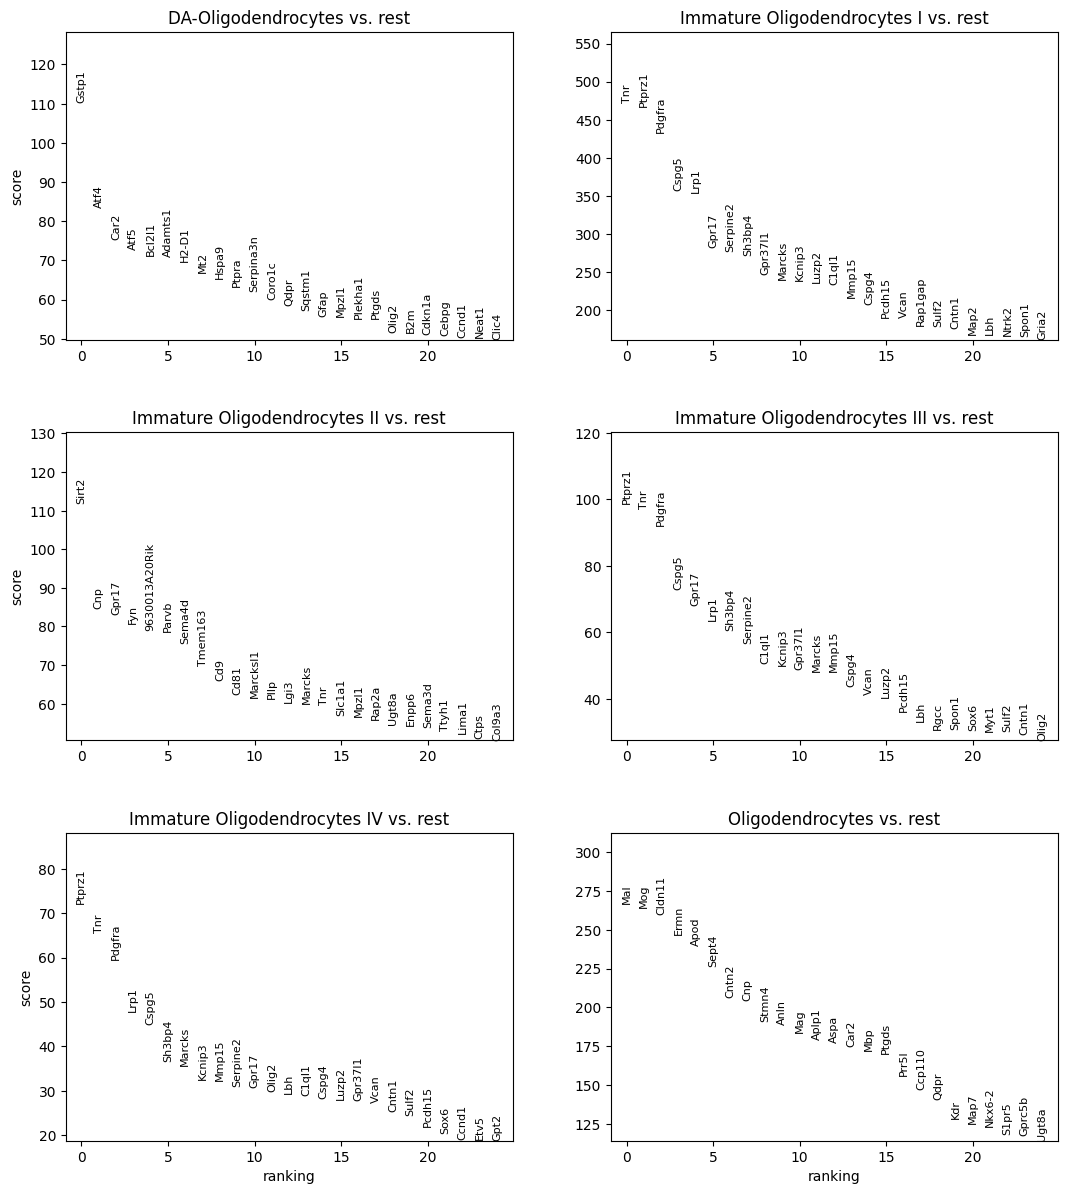

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,DA-Oligodendrocytes,Gstp1,110.164055,2.719675,0.0,0.0
1,DA-Oligodendrocytes,Atf4,83.434509,2.315025,0.0,0.0
2,DA-Oligodendrocytes,Car2,75.182030,1.432262,0.0,0.0
3,DA-Oligodendrocytes,Atf5,72.738533,3.133090,0.0,0.0
4,DA-Oligodendrocytes,Bcl2l1,71.281052,2.240309,0.0,0.0


In [111]:
# --- Find marker genes per cluster ---
sc.tl.rank_genes_groups(adata_OL, groupby="OL_ANNO", method="t-test")
sc.pl.rank_genes_groups(adata_OL, n_genes=25, sharey=False,ncols = 2)

# get a tidy table of top markers
markers = sc.get.rank_genes_groups_df(adata_OL, group=None)
markers.head()

In [137]:
markers

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,DA-Oligodendrocytes,Gstp1,110.164055,2.719675,0.0,0.0
1,DA-Oligodendrocytes,Atf4,83.434509,2.315025,0.0,0.0
2,DA-Oligodendrocytes,Car2,75.182030,1.432262,0.0,0.0
3,DA-Oligodendrocytes,Atf5,72.738533,3.133090,0.0,0.0
4,DA-Oligodendrocytes,Bcl2l1,71.281052,2.240309,0.0,0.0
...,...,...,...,...,...,...
30601,Oligodendrocytes,Ptprz1,-181.454102,-3.591051,0.0,0.0
30602,Oligodendrocytes,Sh3bp4,-182.054153,-4.890653,0.0,0.0
30603,Oligodendrocytes,Pdgfra,-196.210693,-6.641571,0.0,0.0
30604,Oligodendrocytes,Gpr17,-208.448929,-6.467313,0.0,0.0


# Differential Expression Across Oligodendrocyte Subtypes

This analysis compares transcriptional programs across **DA-Oligodendrocytes** and multiple **Immature Oligodendrocyte** states relative to all other oligodendrocytes. The results reveal distinct molecular programs reflecting differentiation, stress adaptation, and immune signaling.

---

## 🧠 Overview

Oligodendrocyte populations display two major transcriptional trajectories:

1. **Differentiation Axis** — from early immature OPC-like cells (Immature I–IV) toward mature, myelinating oligodendrocytes.  
2. **Stress-Adaptation Axis** — diverging into a **damage-associated (DA-OL)** state characterized by stress, metabolic, and immune response programs.

---

## 🔹 DA-Oligodendrocytes
**Top genes:** `Gstp1`, `Atf4`, `Mt2`, `H2-D1`, `Serpina3n`, `Sqstm1`, `Hspa9`

DA-OLs activate a **damage- and stress-adaptive transcriptional program** featuring:
- **Integrated Stress Response (ISR)**: `Atf4`, `Atf5`, `Hspa9`
- **Oxidative / Detoxification**: `Gstp1`, `Mt2`, `Car2`
- **Immune alertness**: `H2-D1`, `B2m`, `Serpina3n`

➡ Represents oligodendrocytes under **mitochondrial or inflammatory stress**, maintaining survival and signaling rather than full myelination.

---

## 🔹 Immature Oligodendrocytes I
**Top genes:** `Ptprz1`, `Pdgfra`, `Lrp1`, `Cspg5`, `Serpinb2`, `Ncam1`, `Sox4`, `Sox11`

- Early **OPC-like** cells with high **growth factor**, **axon–glia**, and **migration** signaling.
- Likely represents **actively differentiating precursors** prior to myelin gene induction.

---

## 🔹 Immature Oligodendrocytes II
**Top genes:** `Sirt2`, `Cnp`, `Plp1`, `Mbp`, `Mal`, `Mog`

- **Pre-myelinating / myelin-forming** stage.  
- Strong induction of **myelin structural genes** alongside metabolic regulators like `Sirt2`.  
- Marks the **metabolic and biosynthetic upshift** toward myelination.

---

## 🔹 Immature Oligodendrocytes III
**Top genes:** `Ptprz1`, `Pdgfra`, `Rgma`, `Sox4`, `Sox11`, `Ncan`, `Lingo1`

- **Reactive or stalled differentiation state**.  
- Expression of inhibitory axon-guidance genes (`Lingo1`, `Rgma`) suggests limited maturation under stress or inflammation.

---

## 🔹 Immature Oligodendrocytes IV
**Top genes:** `Ptprz1`, `Rgma`, `Lrp1`, `Sox4`, `Ncam1`, `Sema5a`

- Shares features with Immature III but stronger **neurite-guidance and ECM interaction** components.  
- May correspond to **migratory or remodeling OL intermediates**.

---

## 🔹 Mature Oligodendrocytes
**Top genes:** `Mbp`, `Plp1`, `Mag`, `Mog`, `Ugt8a`, `Fa2h`, `Gpr37`, `Cldn11`, `Ermn`

- Classical **myelination and lipid metabolism** program.  
- Fully differentiated, energy-efficient OLs maintaining myelin sheath integrity.

---

## 🧩 Summary Table

| State | Functional Identity | Hallmark Features |
|--------|---------------------|-------------------|
| **Immature I** | Early OPC / differentiating | Growth factor signaling, migration |
| **Immature II** | Pre-myelinating | Myelin gene activation, metabolic upshift |
| **Immature III–IV** | Stalled / reactive | Axon-guidance, ECM remodeling |
| **DA-OL** | Stress-adapted | ISR, oxidative defense, MHC-I activation |
| **Mature OL** | Fully myelinating | Lipid biosynthesis, sheath maintenance |

---

📖 **Read more:**  
- `results/OL-lineage/markers.csv`  
- `results/OL-lineage/heatmaps/`  
- `results/DA-OL/README.md`

,sample_id,condition,age,sex,OL_ANNO,n_cells,fraction
0,RB4282,control,21,female,DA-Oligodendrocytes,0,NaN
1,RB4282,control,21,female,Immature Oligodendrocytes I,0,NaN
2,RB4282,control,21,female,Immature Oligodendrocytes II,0,NaN
3,RB4282,control,21,female,Immature Oligodendrocytes III,0,NaN
4,RB4282,control,21,female,Immature Oligodendrocytes IV,0,NaN


,condition,age,sex,OL_ANNO,fraction
5,control,21,female,Oligodendrocytes,0.832237
1,control,21,female,Immature Oligodendrocytes I,0.094025
2,control,21,female,Immature Oligodendrocytes II,0.035917
3,control,21,female,Immature Oligodendrocytes III,0.029996
0,control,21,female,DA-Oligodendrocytes,0.004075


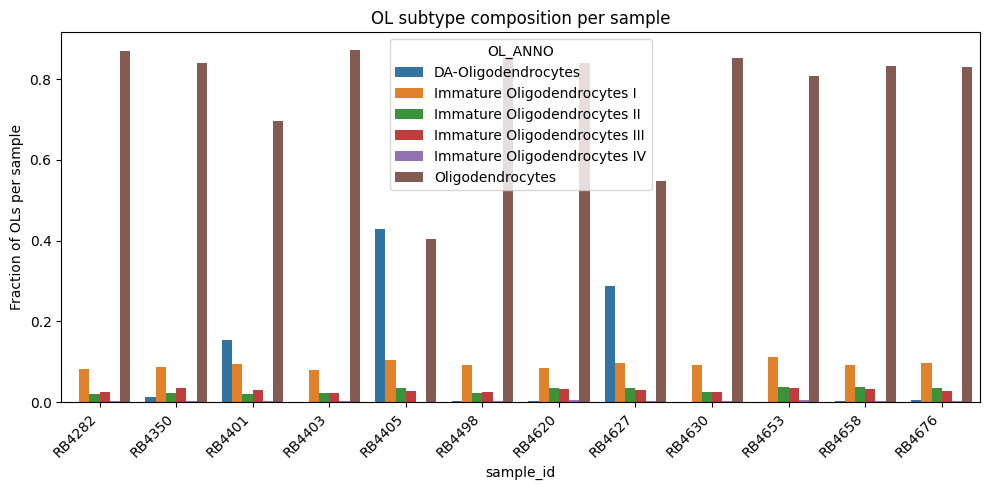

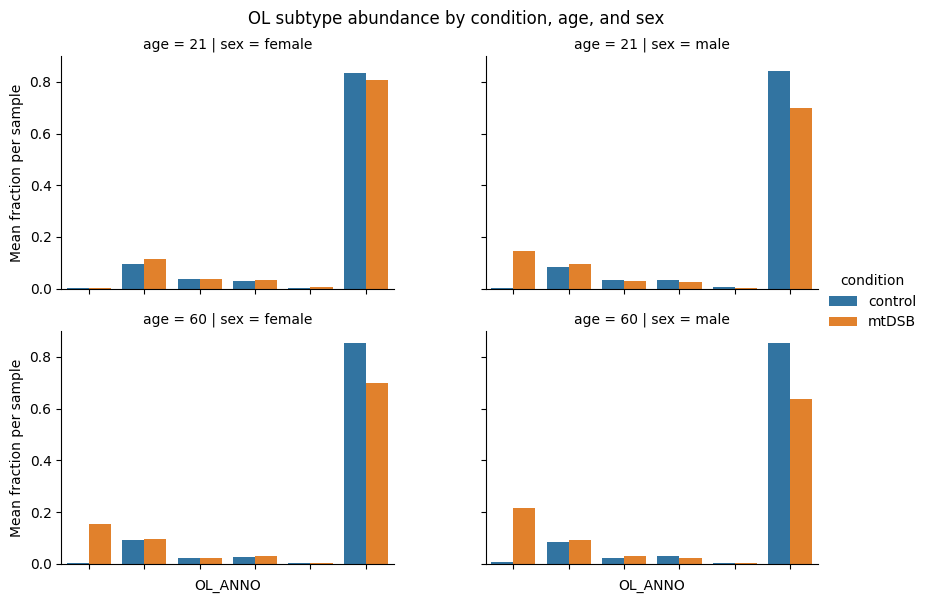

In [124]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Compute per-sample OL_ANNO fractions ---
counts = (
    adata_OL.obs
    .groupby(['sample_id', 'condition', 'age', 'sex', 'OL_ANNO'])
    .size()
    .reset_index(name='n_cells')
)

# Normalize within each sample
counts['fraction'] = (
    counts.groupby(['sample_id', 'condition', 'age', 'sex'])['n_cells']
    .transform(lambda x: x / x.sum())
)

prop = counts.copy()
display(prop.head())

# --- Summary (optional) ---
group_summary = (
    prop.groupby(['condition', 'age', 'sex', 'OL_ANNO'], as_index=False)['fraction']
    .mean()
    .sort_values(['condition', 'age', 'sex', 'fraction'], ascending=[True, True, True, False])
)
display(group_summary.head())

# --- Plot: sample-level stacked composition ---
plt.figure(figsize=(10,5))
sns.barplot(data=prop, x='sample_id', y='fraction', hue='OL_ANNO')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Fraction of OLs per sample')
plt.title('OL subtype composition per sample')
plt.tight_layout()
plt.show()

# --- Faceted view: OL subtype composition by condition/age/sex ---
g = sns.catplot(
    data=prop,
    kind='bar',
    x='OL_ANNO',
    y='fraction',
    hue='condition',
    col='sex',
    row='age',
    estimator='mean',
    errorbar=None,
    height=3.0,
    aspect=1.4
)
g.set_xticklabels(rotation=45, ha='right')
g.set_ylabels('Mean fraction per sample')
g.fig.suptitle('OL subtype abundance by condition, age, and sex', y=1.02)
plt.show()

In [125]:
adata

AnnData object with n_obs × n_vars = 980474 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'n_genes_by_counts', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_2', 'cell_class', 'sample_id', 'age', 'sex', 'genotype', 'condition', 'cell_type', 'cell_id', 'rbd_domain_0.1', 'rbd_domain_0.2', 'rbd_domain_0.5', 'rbd_domain_1.0', 'RBD_compartment', 'RBD_compartment_simplified', 'leiden_1.5', 'leiden_2.1', 'leiden_2.3', 'leiden_2.5', 'leiden_3'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'RBD_compartment_colors', 'RBD_compartment_simplified_colors', 'cell_class_colors', 'cell_type_colors', 'dendrogram_cell_class', 'leiden', 'leiden_0.5_colors', 'leiden_1_colors', 'leiden_2_colors', 'log1p', '

In [126]:
adata_OL

AnnData object with n_obs × n_vars = 187991 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'n_genes_by_counts', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_2', 'cell_class', 'sample_id', 'age', 'sex', 'genotype', 'condition', 'cell_type', 'cell_id', 'rbd_domain_0.1', 'rbd_domain_0.2', 'rbd_domain_0.5', 'rbd_domain_1.0', 'RBD_compartment', 'RBD_compartment_simplified', 'leiden_1.5', 'leiden_2.1', 'leiden_2.3', 'leiden_2.5', 'leiden_3', 'OL_louvain_1.0', 'score_OPC', 'score_COP', 'score_NFOL', 'score_MOL_myelin', 'score_DOL_core', 'score_ISR', 'score_IFN', 'score_Astro_react', 'score_Immune_AP', 'score_MaturationZ', 'score_DiseaseZ', 'score_ImmuneZ', 'score_AstroReactZ', 'OL_ANNO', 'OL_louvain_1.1', 'OL_louvain_1.3'
    var: 'n_cell

In [128]:
import pandas as pd

# --- 1. Build mapping from OL subset (cell_id → OL_ANNO) ---
ol_map = (
    adata_OL.obs[["cell_id", "OL_ANNO"]]
    .dropna()
    .set_index("cell_id")["OL_ANNO"]
)

# --- 2. Ensure 'cell_class' exists in main object ---
if "cell_class" not in adata.obs.columns:
    adata.obs["cell_class"] = None

# --- 3. Convert to string type (avoids Categorical assignment errors) ---
adata.obs["cell_class"] = adata.obs["cell_class"].astype(str)

# --- 4. Create mask for overlapping cell_ids ---
mask = adata.obs["cell_id"].isin(ol_map.index)

# --- 5. Update only overlapping cells ---
adata.obs.loc[mask, "cell_class"] = adata.obs.loc[mask, "cell_id"].map(ol_map)

# --- 6. (Optional) Convert back to category for memory efficiency ---
adata.obs["cell_class"] = adata.obs["cell_class"].astype("category")

# --- 7. Sanity check ---
n_updated = mask.sum()
print(f"✅ Updated 'cell_class' for {n_updated} OL cells — all other cells left unchanged.")

✅ Updated 'cell_class' for 187991 OL cells — all other cells left unchanged.


In [130]:
adata.write('../data/mtDNA_DSB_5k_clustered_annotation_with_rbd_OL_updated.h5ad')